In [1]:
from caimira.ventilation.ventilation import *
from caimira.ventilation.scenarios import *
from caimira.ventilation.get_models import *

TODO: scale limit by number of occupants to make sense of scenarios where people come and go

In [2]:
scenario = scenarios.shared_office()

air_exch_val = [0.25]
vent_tr_times = [0,1]

lim_probability_infection_list = [0.1, 0.05]
lim_probability_infection = lim_probability_infection_list[0]

0 ACH   =>   P(I) = 12.58%, Dose = 7.90


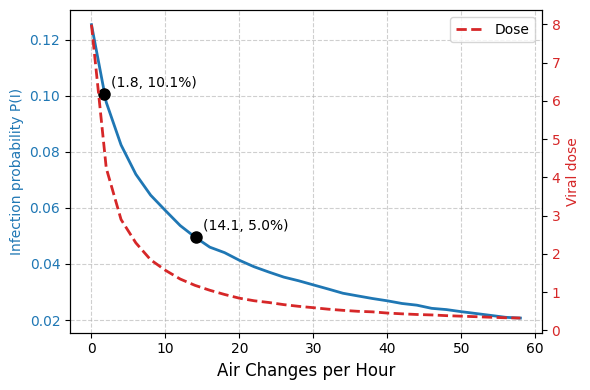

In [3]:
plot_probabilities(lim_probability_infection_list, scenario=scenario)

In [4]:
air_exch, probability = find_constant_air_exch(lim_probability_infection, scenario)

NOTE:

Variability between model runs may cause the probability of infection to be slightly higher than lim_probability_infection.

Inhaled dose:  4.5377 [0.0 - 21.0]
Probability of infection:  0.1007 [0.0 - 1.0]
Max average CO2: 1389.26
Air changes per hour: 1.79


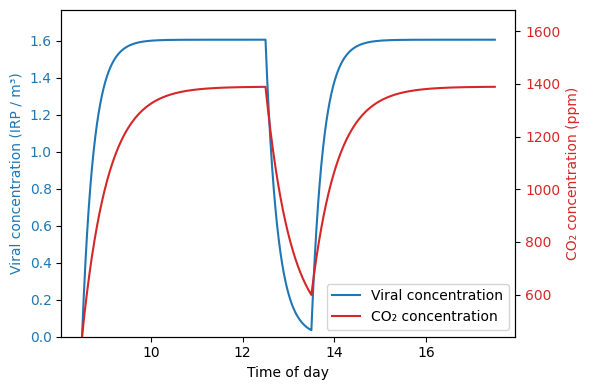

In [5]:
plot_model_concentration_results(air_exch, scenario=scenario, deterministic_CO2=True)

In [6]:
air_exch_l, vent_transition_t = find_next_air_exch_by_co2(
    air_exch_list=[0.25], 
    vent_transition_times=[0,0.001], 
    max_CO2=1400,
    scenario=scenario,
    min_CO2_fraction=0.9,
    max_ventilation_changes=5 
)

In [7]:
for a, v in zip(air_exch_l, vent_transition_t):
    print(v, a)

0 0.25
0.001 2.1062961938242686
10.300000000000068 1.0531480969121343
12.100000000000136 2.1057795690858123
15.687000000000083 1.0528897845429062


NOTE: 

When the number of ventilation changes is defined as less than the model's number of state changes, the CO2 concentration may increase beyond the max CO2 limit (and similarly below the min CO2 limit). 

This also means that the probability of infection is not neccecarily <= lim_probability_infection. 

Inhaled dose:  4.7561 [0.0 - 22.0]
Probability of infection:  0.1028 [0.0 - 1.0]
Max average CO2: 1933.79
Air changes per hour: [0.25, np.float64(2.11), np.float64(1.05), np.float64(2.11), np.float64(1.05)]


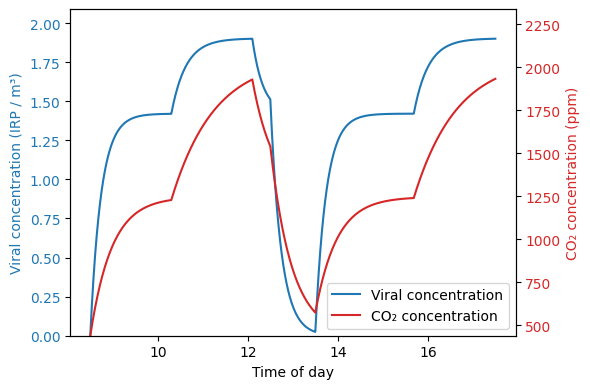

In [8]:
plot_model_concentration_results(air_exch_l, vent_transition_t, scenario=scenario)